DATA ANALYSIS INTERNSHIP (LEVEL BY LEVEL)

In [1]:
import pandas as pd
data = pd.read_csv('Dataset .csv')

In [2]:
print(data.head())
print(data.tail())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [4]:
print(data.describe())

       Restaurant ID  Country Code    Longitude     Latitude  \
count   9.551000e+03   9551.000000  9551.000000  9551.000000   
mean    9.051128e+06     18.365616    64.126574    25.854381   
std     8.791521e+06     56.750546    41.467058    11.007935   
min     5.300000e+01      1.000000  -157.948486   -41.330428   
25%     3.019625e+05      1.000000    77.081343    28.478713   
50%     6.004089e+06      1.000000    77.191964    28.570469   
75%     1.835229e+07      1.000000    77.282006    28.642758   
max     1.850065e+07    216.000000   174.832089    55.976980   

       Average Cost for two  Price range  Aggregate rating         Votes  
count           9551.000000  9551.000000       9551.000000   9551.000000  
mean            1199.210763     1.804837          2.666370    156.909748  
std            16121.183073     0.905609          1.516378    430.169145  
min                0.000000     1.000000          0.000000      0.000000  
25%              250.000000     1.000000        

In [5]:
data = (data.drop_duplicates())

In [38]:
print(data.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Rating Range            0
pairs                   0
cluster                 0
dtype: int64


LEVEL 1

Task 1

In [10]:
cuisine_counts = data['Cuisines'].value_counts()
top_cuisines = cuisine_counts.head(3)
total_restaurants = len(data)
percentages = (top_cuisines / total_restaurants) * 100
result = pd.DataFrame({
    'Cuisines': top_cuisines.index,
    'Count': top_cuisines.values,
    'Percentage': percentages.values.round(2)
})
print(result)


                Cuisines  Count  Percentage
0           North Indian    936        9.80
1  North Indian, Chinese    511        5.35
2                Chinese    354        3.71


Task 2

In [135]:
city_counts = data['City'].value_counts()
city_counts.idxmax()

'New Delhi'

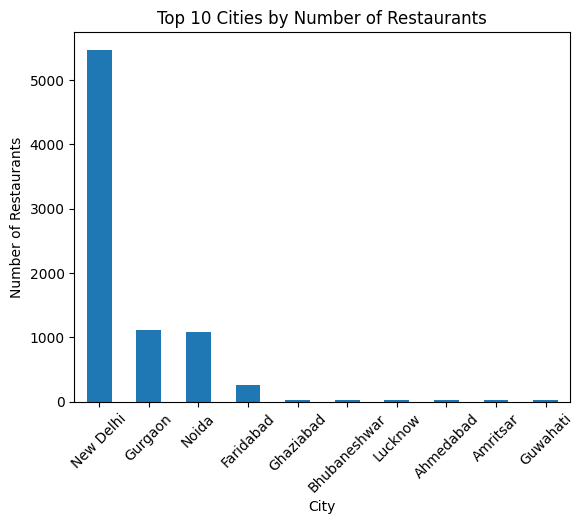

In [137]:
import matplotlib.pyplot as plt

city_counts.head(10).plot(kind="bar")
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

In [138]:
avg_ratings = data.groupby('City')['Aggregate rating'].idxmax()
print("Average rating per city:\n", avg_ratings)

Average rating per city:
 City
Abu Dhabi           580
Agra                637
Ahmedabad           653
Albany               89
Allahabad           680
                   ... 
Weirton             561
Wellington City    9321
Winchester Bay      562
Yorkton             563
��stanbul          9538
Name: Aggregate rating, Length: 141, dtype: int64


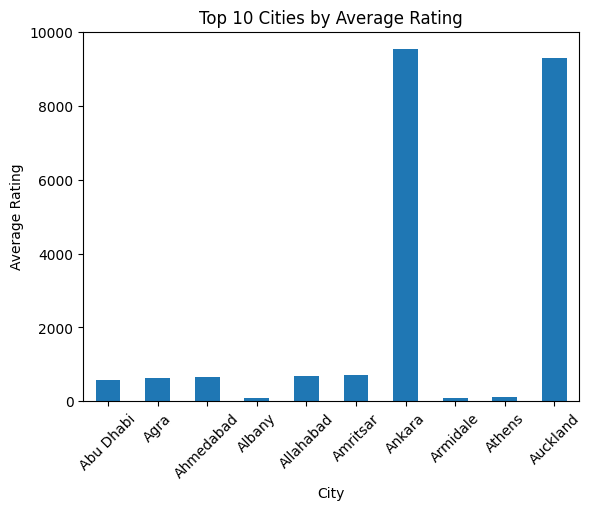

In [141]:
avg_ratings.head(10).plot(kind="bar")
plt.title("Top 10 Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

In [139]:
top_city = avg_ratings.idxmax()
top_rating = avg_ratings.max()
print(f"\nCity with highest average rating: {top_city} ({top_rating:.2f})")



City with highest average rating: ��stanbul (9538.00)


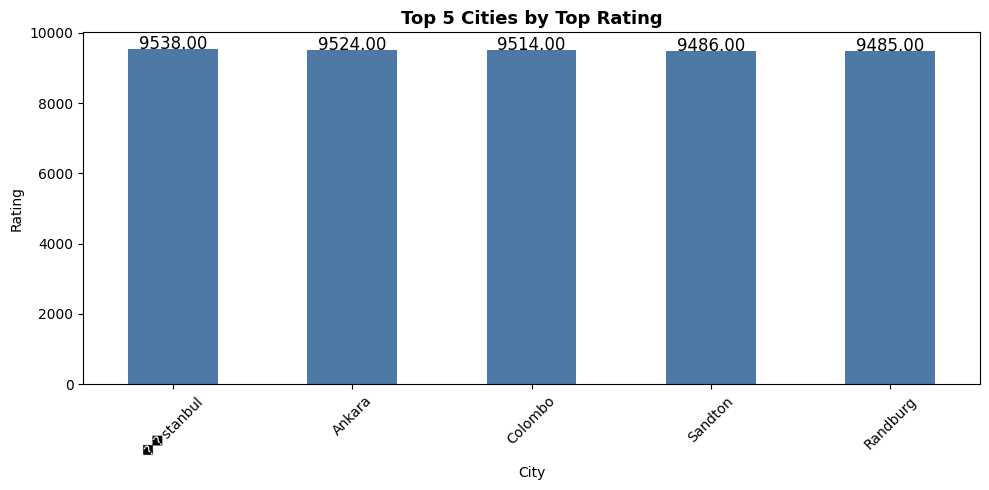

In [165]:

top_avg = avg_ratings.sort_values(ascending=False).head(5)

plt.figure(figsize=(10,5))
ax = top_avg.plot(kind="bar", color="#4E79A7")

plt.title("Top 5 Cities by Top Rating", fontweight='bold', fontsize=13)
plt.xlabel("City")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.tight_layout()

for i, v in enumerate(top_avg.values):
    ax.text(i, v + 0.02, f"{v:.2f}", 
            ha='center', fontsize=12)
    
plt.show()

Task 3


C:\Users\Ahammed Ijlal\AppData\Local\Temp\ipykernel_3448\557244429.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_counts.index, y=price_counts.values, palette="viridis")


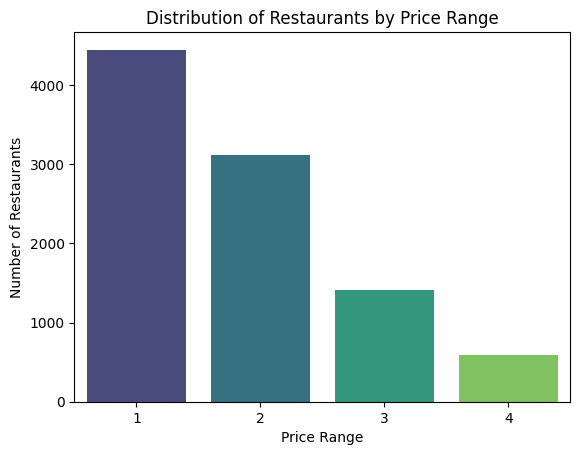

In [ ]:
import seaborn as sns
price_counts = data['Price range'].value_counts()
sns.barplot(x=price_counts.index, y=price_counts.values, palette="viridis")
plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()


In [15]:

price_percentages = data['Price range'].value_counts(normalize=True) * 100
print("Percentage of restaurants in each price range:\n", price_percentages.mode())


Percentage of restaurants in each price range:
 0     6.135483
1    14.741912
2    32.593446
3    46.529159
Name: proportion, dtype: float64


C:\Users\Ahammed Ijlal\AppData\Local\Temp\ipykernel_3448\2637619385.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_percentages.index, y=price_percentages.values, palette="plasma", ax=axes[0])


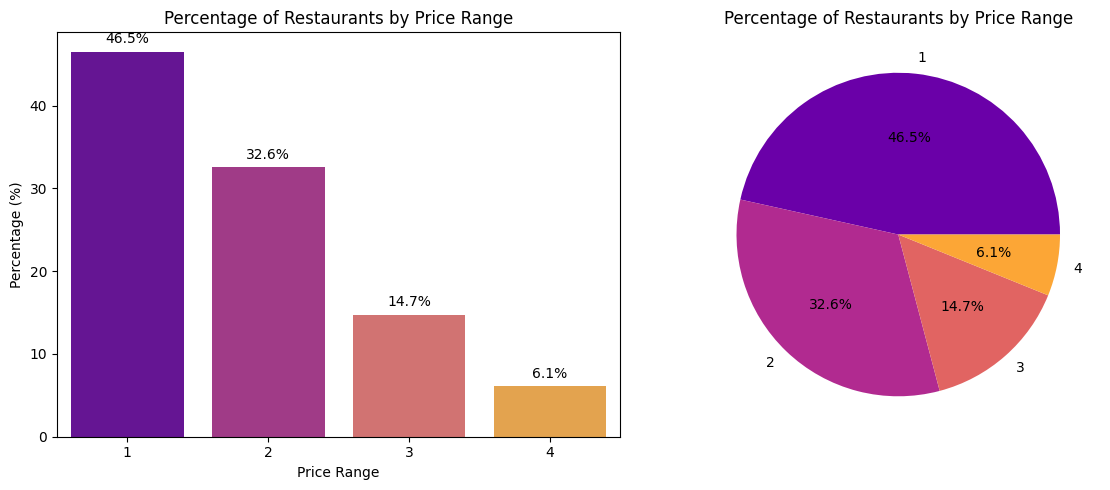

In [164]:

price_percentages = data['Price range'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=price_percentages.index, y=price_percentages.values, palette="plasma", ax=axes[0])
axes[0].set_title("Percentage of Restaurants by Price Range")
axes[0].set_xlabel("Price Range")
axes[0].set_ylabel("Percentage (%)")

for i, v in enumerate(price_percentages.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

axes[1].pie(price_percentages.values, labels=price_percentages.index, autopct='%1.1f%%', colors=sns.color_palette("plasma", len(price_percentages)))
axes[1].set_title("Percentage of Restaurants by Price Range")

plt.tight_layout()
plt.show()

Task 4


In [17]:
delivery_counts = data['Has Online delivery'].value_counts(normalize=True) * 100
print("Percentage of restaurants offering online delivery:\n", delivery_counts)

Percentage of restaurants offering online delivery:
 Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


C:\Users\Ahammed Ijlal\AppData\Local\Temp\ipykernel_3448\1382096938.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delivery_counts, y=delivery_counts.values, palette="plasma")


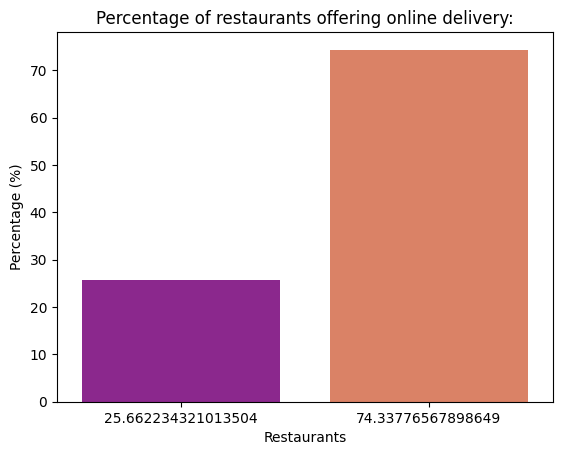

In [18]:
sns.barplot(x=delivery_counts, y=delivery_counts.values, palette="plasma")
plt.title("Percentage of restaurants offering online delivery:")
plt.xlabel("Restaurants")
plt.ylabel("Percentage (%)")
plt.show()

In [19]:
avg_ratings = data.groupby('Has Online delivery')['Aggregate rating'].mean()
print("\nAverage ratings comparison:\n", avg_ratings)



Average ratings comparison:
 Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


C:\Users\Ahammed Ijlal\AppData\Local\Temp\ipykernel_3448\357187397.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_ratings.index, y=avg_ratings.values, palette="coolwarm")


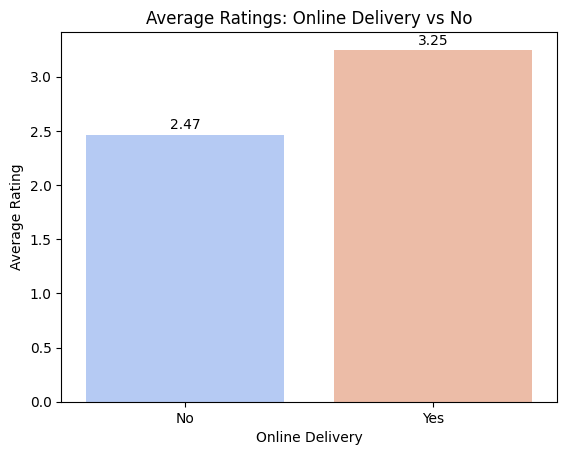

In [ ]:

sns.barplot(x=avg_ratings.index, y=avg_ratings.values, palette="coolwarm")
plt.title("Average Ratings: Online Delivery vs No")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

for i, v in enumerate(avg_ratings.values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=10)

plt.show()


LEVEL 2

Task 1

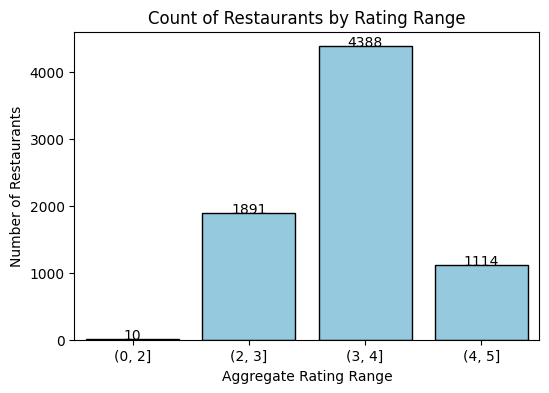

In [26]:

data['Rating Range'] = pd.cut(data['Aggregate rating'], bins=[0,2,3,4,5])

plt.figure(figsize=(6,4))
sns.countplot(x='Rating Range', data=data, color="skyblue", edgecolor="black")
plt.title("Count of Restaurants by Rating Range")
plt.xlabel("Aggregate Rating Range")
plt.ylabel("Number of Restaurants")

counts = data['Rating Range'].value_counts().sort_index()
for i, v in enumerate(counts.values):
    plt.text(i, v + 0.2, str(v), ha='center', fontsize=10)

plt.show()


In [22]:
rating_counts = pd.cut(data['Aggregate rating'], bins=[0,2,3,4,5]).value_counts()
most_common_range = rating_counts.idxmax()
print("Most common rating range:", most_common_range)

Most common rating range: (3, 4]


In [23]:
avg_votes = data['Votes'].mean()
print("Average number of votes received by restaurants:", avg_votes)

Average number of votes received by restaurants: 156.909747670401


Task 2

Top 10 most common cuisines Combinations:

Cuisines
[['North Indian']]                              936
[['North Indian',  ' Chinese']]                 511
[['Fast Food']]                                 354
[['Chinese']]                                   354
[['North Indian',  ' Mughlai']]                 334
[['Cafe']]                                      299
[['Bakery']]                                    218
[['North Indian',  ' Mughlai',  ' Chinese']]    197
[['Bakery',  ' Desserts']]                      170
[['Street Food']]                               149
Name: count, dtype: int64


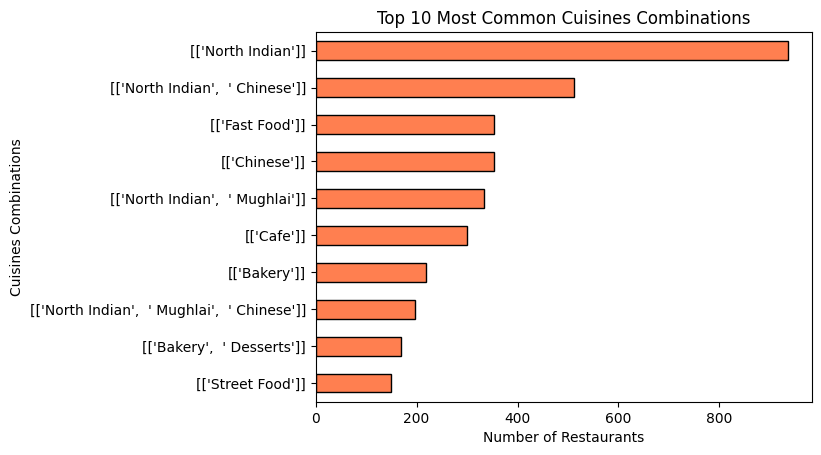

In [117]:
cuisine_counts = data['Cuisines'].value_counts().head(10)

print("Top 10 most common cuisines Combinations:\n")
print(cuisine_counts)

plt.figure()
cuisine_counts.plot(kind='barh', color='coral', edgecolor='black')
plt.title("Top 10 Most Common Cuisines Combinations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisines Combinations")
plt.gca().invert_yaxis()
plt.show()


Top 30 Cuisines with Highest Average Ratings:

Cuisines
["['American'", " ' BBQ'", " ' Sandwich']"]                  4.900000
["['World Cuisine']"]                                        4.900000
["['Burger'", " ' Bar Food'", " ' Steak']"]                  4.900000
["['American'", " ' Caribbean'", " ' Seafood']"]             4.900000
["['American'", " ' Coffee and Tea']"]                       4.900000
["['European'", " ' Asian'", " ' Indian']"]                  4.900000
["['Continental'", " ' Indian']"]                            4.900000
["['European'", " ' Contemporary']"]                         4.900000
["['Hawaiian'", " ' Seafood']"]                              4.900000
["['BBQ'", " ' Breakfast'", " ' Southern']"]                 4.900000
["['European'", " ' German']"]                               4.900000
["['American'", " ' Burger'", " ' Grill']"]                  4.900000
["['Mughlai'", " ' Lucknowi']"]                              4.900000
["['Italian'", " ' Deli']"]      

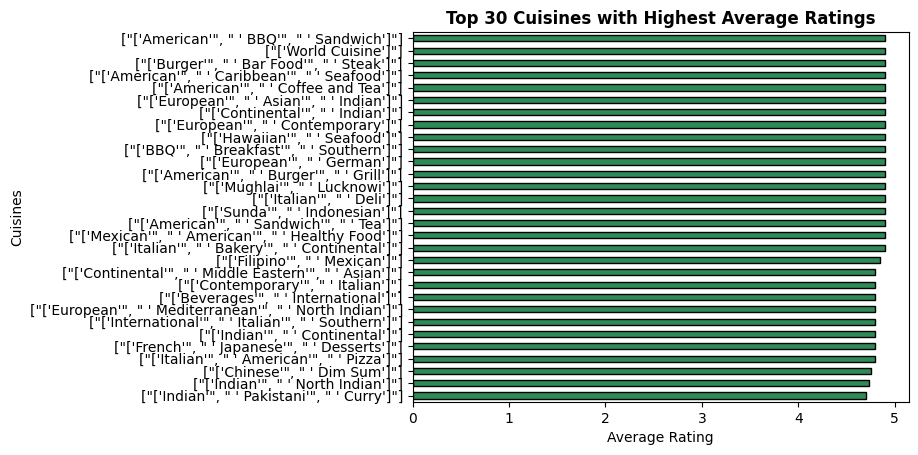

In [129]:
data['Cuisines'] = data['Cuisines'].astype(str)
cuisine_rating = (data.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(30))
print("\nTop 30 Cuisines with Highest Average Ratings:\n")
print(cuisine_rating)

plt.figure()
cuisine_rating.plot(kind='barh', color='seagreen', edgecolor='black')
plt.title("Top 30 Cuisines with Highest Average Ratings", fontsize=12, fontweight='bold')
plt.xlabel("Average Rating")
plt.ylabel("Cuisines")
plt.gca().invert_yaxis()
plt.show()


Top 10 Cuisines with Highest Average Ratings:

Cuisines
["['American'", " ' BBQ'", " ' Sandwich']"]         4.9
["['World Cuisine']"]                               4.9
["['Burger'", " ' Bar Food'", " ' Steak']"]         4.9
["['American'", " ' Caribbean'", " ' Seafood']"]    4.9
["['American'", " ' Coffee and Tea']"]              4.9
["['European'", " ' Asian'", " ' Indian']"]         4.9
["['Continental'", " ' Indian']"]                   4.9
["['European'", " ' Contemporary']"]                4.9
["['Hawaiian'", " ' Seafood']"]                     4.9
["['BBQ'", " ' Breakfast'", " ' Southern']"]        4.9
Name: Aggregate rating, dtype: float64


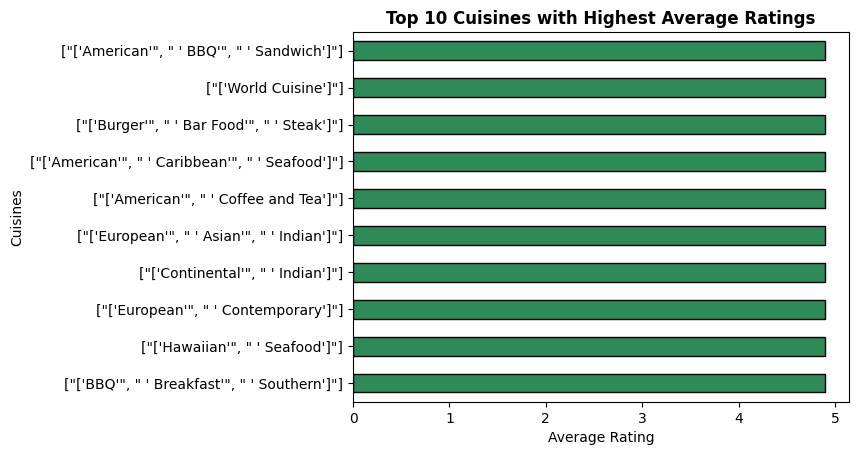

In [131]:
data['Cuisines'] = data['Cuisines'].astype(str)
cuisine_rating = (data.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(10))
print("\nTop 10 Cuisines with Highest Average Ratings:\n")
print(cuisine_rating)

plt.figure()
cuisine_rating.plot(kind='barh', color='seagreen', edgecolor='black')
plt.title("Top 10 Cuisines with Highest Average Ratings", fontweight='bold')
plt.xlabel("Average Rating")
plt.ylabel("Cuisines")
plt.gca().invert_yaxis()
plt.show()



Task 3

C:\Users\Ahammed Ijlal\AppData\Local\Temp\ipykernel_3448\4127087621.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = 'Cuisines', loc = 'best')


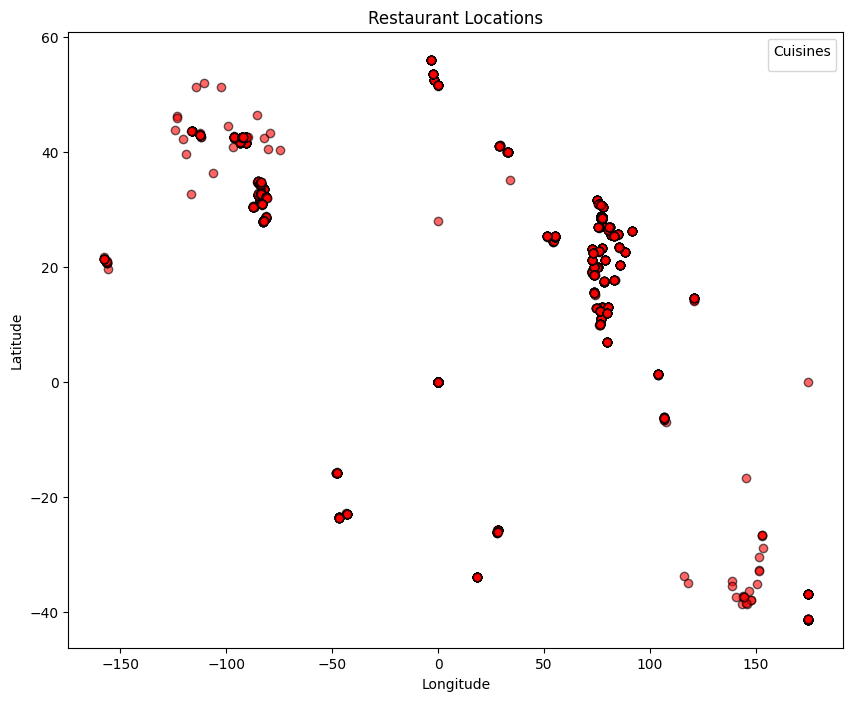

In [29]:
plt.figure(figsize=(10,8))
plt.scatter(data['Longitude'], data['Latitude'], 
            c='red', alpha=0.6, edgecolors='k')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Restaurant Locations")
plt.legend(title = 'Cuisines', loc = 'best')
plt.show()


C:\Users\Ahammed Ijlal\AppData\Local\Temp\ipykernel_3448\1289950365.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = 'Cuisines', loc = 'best', bbox_to_anchor=(1.02, 1), frameon = True, fancybox = True, shadow = True, borderpad = 1 )


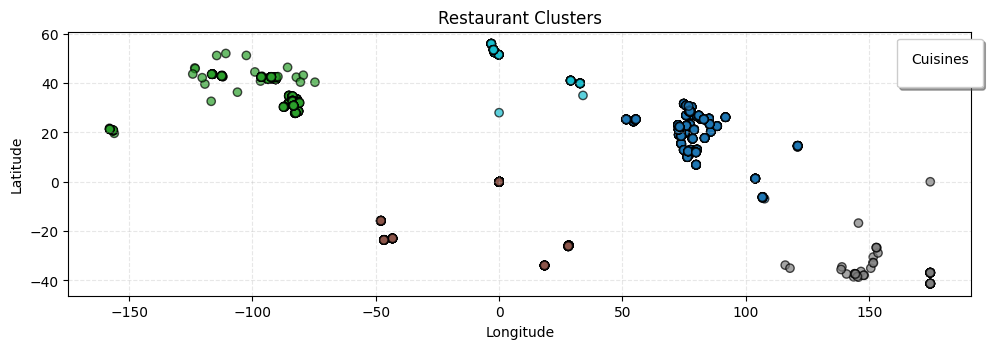

In [30]:
from sklearn.cluster import KMeans

coords = data[['Longitude', 'Latitude']]
kmeans = KMeans(n_clusters=5, random_state=42).fit(coords)

data['cluster'] = kmeans.labels_

plt.figure(figsize=(10,8))
plt.scatter(data['Longitude'], data['Latitude'], 
            c=data['cluster'], cmap='tab10', alpha=0.7, edgecolors='k')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Restaurant Clusters")
plt.legend(title = 'Cuisines', loc = 'best', bbox_to_anchor=(1.02, 1), frameon = True, fancybox = True, shadow = True, borderpad = 1 )

plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

Task 4

In [31]:
chain_counts = data['Restaurant Name'].value_counts()

chains = chain_counts[chain_counts > 1].index
df_chains = data[data['Restaurant Name'].isin(chains)]

chain_analysis = df_chains.groupby('Restaurant Name').agg({
    'Aggregate rating': 'mean',      
    'Votes': 'sum' 
})

chain_analysis['outlet_count'] = df_chains.groupby('Restaurant Name').size()

chain_analysis = chain_analysis.sort_values(by='Votes', ascending=False)

print(chain_analysis.head(10))


                           Aggregate rating  Votes  outlet_count
Restaurant Name                                                 
Barbeque Nation                    4.353846  28142            26
AB's - Absolute Barbecues          4.825000  13400             4
Big Chill                          4.475000  10853             4
Farzi Cafe                         4.366667  10098             6
Truffles                           3.950000   9682             2
Chili's                            4.580000   8156             5
Joey's Pizza                       4.250000   7807             2
Big Yellow Door                    4.266667   7511             3
Saravana Bhavan                    4.133333   7238             3
Starbucks                          3.805556   7139            18


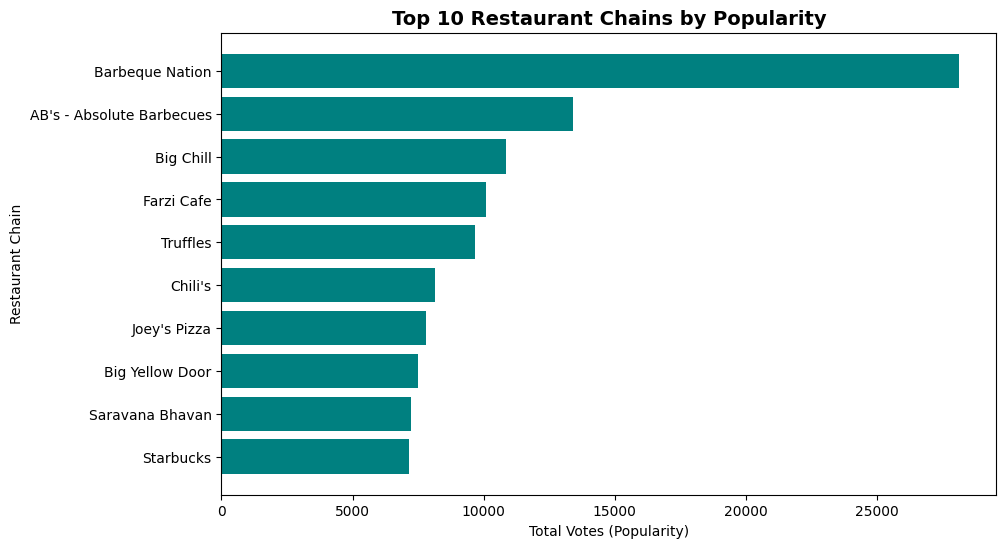

In [32]:

top_chains = chain_analysis.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_chains.index, top_chains['Votes'], color='teal')
plt.xlabel("Total Votes (Popularity)")
plt.ylabel("Restaurant Chain")
plt.title("Top 10 Restaurant Chains by Popularity", fontsize=14, fontweight='bold')
plt.gca().invert_yaxis() 
plt.show()

LEVEL 3

Task 1

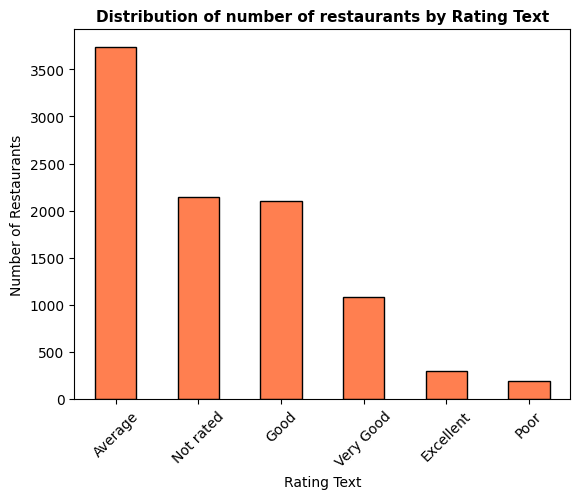

In [52]:
rating_counts = data['Rating text'].value_counts()

plt.figure()
rating_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Distribution of number of restaurants by Rating Text", fontsize=11, fontweight='bold')
plt.xlabel("Rating Text")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

In [58]:
data["rating text length"] = data['Rating text'].astype(str).apply(len)

average_length = data['rating text length'].mean()
print("\nAverage Rating Text Length:", round(average_length, 2))


Average Rating Text Length: 7.02


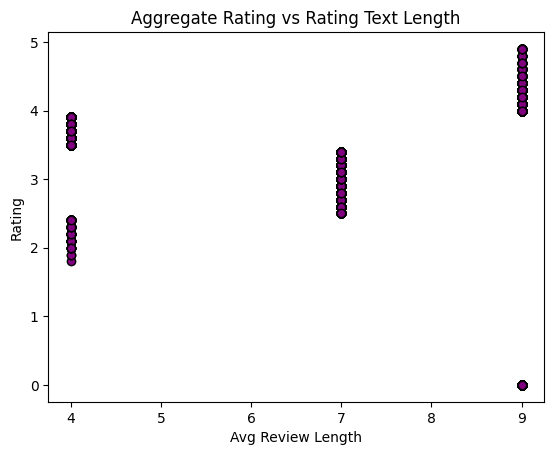

In [67]:
plt.figure()
plt.scatter(data['rating text length'], data['Aggregate rating'], color='purple', edgecolors='k')
plt.title("Aggregate Rating vs Rating Text Length")
plt.xlabel("Avg Review Length")
plt.ylabel("Rating")
plt.show()

Task 2

In [83]:
highest_votes = data.loc[data["Votes"].idxmax()]
print("\nRestaurant with highest votes:\n")
print(highest_votes[["Restaurant Name", "City", "Votes", "Aggregate rating"]])



Restaurant with highest votes:

Restaurant Name          Toit
City                Bangalore
Votes                   10934
Aggregate rating          4.8
Name: 728, dtype: object


In [86]:
highest_votes = data.loc[data["Votes"].idxmin()]
print("\nRestaurant with lowest votes:\n")
print(highest_votes[["Restaurant Name", "City", "Votes", "Aggregate rating"]])


Restaurant with lowest votes:

Restaurant Name     Cantinho da Gula
City                      S��o Paulo
Votes                              0
Aggregate rating                 0.0
Name: 69, dtype: object


In [89]:
correlation = data['Votes'].corr(data['Aggregate rating'])

print("\nCorrelation between Votes and Aggregate rating:", round(correlation, 4))


Correlation between Votes and Aggregate rating: 0.3137


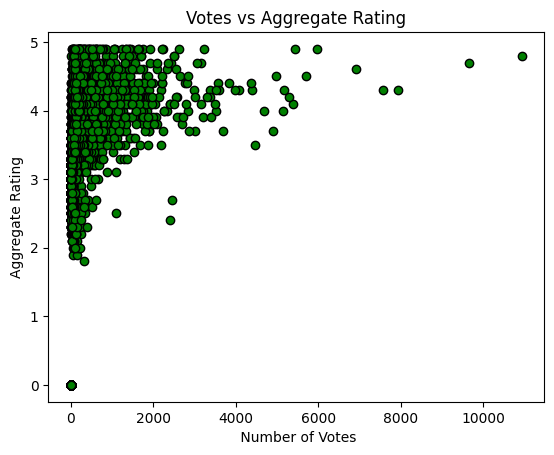

In [92]:
plt.figure()
plt.scatter(data["Votes"], data['Aggregate rating'], color='green', edgecolors='k')
plt.title("Votes vs Aggregate Rating")
plt.xlabel(" Number of Votes")
plt.ylabel("Aggregate Rating")
plt.show()

Task 3


In [94]:
print(data[["Price range", "Has Online delivery", "Has Table booking"]].head())

   Price range Has Online delivery Has Table booking
0            3                  No               Yes
1            3                  No               Yes
2            4                  No               Yes
3            4                  No                No
4            4                  No               Yes



Online Delivery by Price Range:

Has Online delivery    No   Yes
Price range                    
1                    3743   701
2                    1827  1286
3                     997   411
4                     533    53


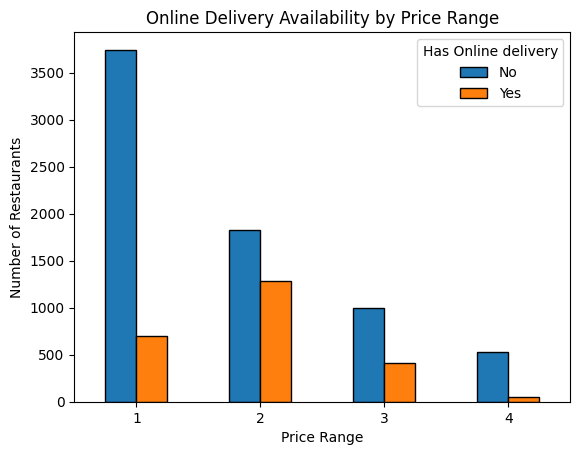

In [107]:
online_delivery = pd.crosstab(data["Price range"], data["Has Online delivery"])

print("\nOnline Delivery by Price Range:\n")
print(online_delivery)

online_delivery.plot(kind="bar", edgecolor="black",)
plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.show()


Table Booking by Price Range:

Has Table booking    No  Yes
Price range                 
1                  4443    1
2                  2874  239
3                   764  644
4                   312  274


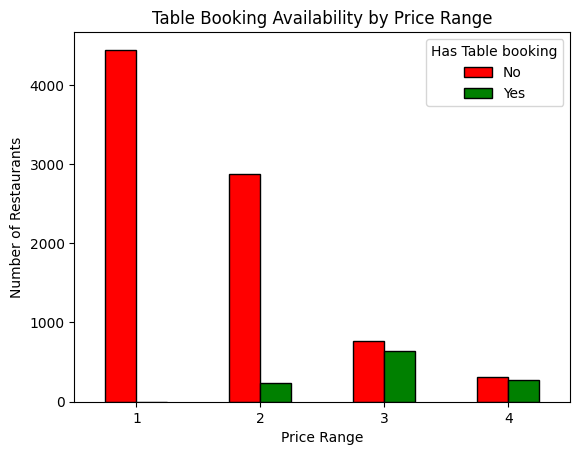

In [106]:
table_booking = pd.crosstab(data["Price range"], data["Has Table booking"])

print("\nTable Booking by Price Range:\n")
print(table_booking)

table_booking.plot(kind="bar", color=["red", "green"], edgecolor="black")
plt.title("Table Booking Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.show()


In [103]:
online_percentage = online_delivery.div(online_delivery.sum(axis=1), axis=0) * 100
booking_percentage = table_booking.div(table_booking.sum(axis=1), axis=0) * 100

print("\nOnline Delivery Percentage by Price Range:\n")
print(online_percentage)

print("\nTable Booking Percentage by Price Range:\n")
print(booking_percentage)


Online Delivery Percentage by Price Range:

Has Online delivery         No        Yes
Price range                              
1                    84.225923  15.774077
2                    58.689367  41.310633
3                    70.809659  29.190341
4                    90.955631   9.044369

Table Booking Percentage by Price Range:

Has Table booking         No        Yes
Price range                            
1                  99.977498   0.022502
2                  92.322518   7.677482
3                  54.261364  45.738636
4                  53.242321  46.757679


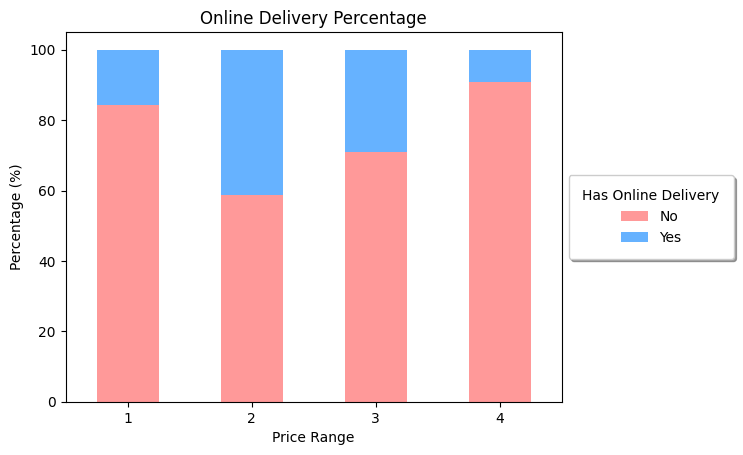

In [166]:

online_percentage.plot(
    kind="bar",
    stacked=True,
    color=["#FF9999", "#66B2FF"]
)

plt.title("Online Delivery Percentage")
plt.xlabel("Price Range")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Has Online Delivery", loc="center left", bbox_to_anchor=(1, 0.5), frameon=True, fancybox=True, shadow=True, borderpad=1)
plt.show()